---

## LogBERT — Log Anomaly Detection via BERT

Реализация по статье: **LogBERT: Log Anomaly Detection via BERT** (Guo et al., 2021).

**Пайплайн:**
1. Словарь строится из уникальных Event ID (e.g. `E5`, `E22`, …).
2. BERT обучается только на *нормальных* сессиях.
3. Во время обучения используются две self-supervised задачи:
   - **Masked Log Key Prediction**: предсказание случайно замаскированных событий.
   - **Hypersphere / Center objective**: embeddings нормальных последовательностей стягиваются к общему центру в пространстве представлений.
4. На инференсе считаются две аномальные компоненты: MLM-ошибка и расстояние до центра.
5. Итоговый **anomaly score** строится как взвешенная комбинация этих двух компонент.
6. Порог выбирается по 95-му перцентилю скоров нормальных сессий из val-выборки.

## 1. Конфигурация LogBERT

Ниже собраны все ключевые гиперпараметры: архитектура, обучение, инференс и веса итогового anomaly score. Конфиг оформлен одним словарем, чтобы его было проще менять и сохранять вместе с результатами.


In [9]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import (
    BertConfig,
    BertForMaskedLM,
    get_linear_schedule_with_warmup,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, roc_curve,
    precision_recall_curve,
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

CONFIG = {
    "seed": 42,
    "model": {
        "window_size": 96,
        "hidden_size": 192,
        "num_layers": 3,
        "num_heads": 4,
        "intermediate_size": 768,
        "dropout": 0.1,
    },
    "training": {
        "mask_prob": 0.15,
        "epochs": 4,
        "batch_size": 16,
        "lr": 1e-3,
        "warmup_ratio": 0.05,
        "patience": 5,
        "center_loss_weight": 0.1,
        "center_warmup_epoch": 2,
    },
    "inference": {
        "top_g": 9,
        "infer_rounds": 3,
        "infer_batch": 64,
        "mlm_score_weight": 0.5,
        "center_score_weight": 0.5,
    },
}

SEED = CONFIG["seed"]
WINDOW_SIZE = CONFIG["model"]["window_size"]
HIDDEN_SIZE = CONFIG["model"]["hidden_size"]
NUM_LAYERS = CONFIG["model"]["num_layers"]
NUM_HEADS = CONFIG["model"]["num_heads"]
INTERMEDIATE = CONFIG["model"]["intermediate_size"]
DROPOUT = CONFIG["model"]["dropout"]
MASK_PROB = CONFIG["training"]["mask_prob"]
EPOCHS = CONFIG["training"]["epochs"]
BATCH_SIZE = CONFIG["training"]["batch_size"]
LR = CONFIG["training"]["lr"]
WARMUP_RATIO = CONFIG["training"]["warmup_ratio"]
PATIENCE = CONFIG["training"]["patience"]
CENTER_LOSS_WEIGHT = CONFIG["training"]["center_loss_weight"]
CENTER_WARMUP_EPOCH = CONFIG["training"]["center_warmup_epoch"]
TOP_G = CONFIG["inference"]["top_g"]
INFER_ROUNDS = CONFIG["inference"]["infer_rounds"]
INFER_BATCH = CONFIG["inference"]["infer_batch"]
MLM_SCORE_WEIGHT = CONFIG["inference"]["mlm_score_weight"]
CENTER_SCORE_WEIGHT = CONFIG["inference"]["center_score_weight"]

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

config_df = pd.DataFrame([
    {
        "seed": SEED,
        "device": DEVICE,
        "window_size": WINDOW_SIZE,
        "mask_prob": MASK_PROB,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "num_heads": NUM_HEADS,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LR,
        "center_loss_weight": CENTER_LOSS_WEIGHT,
        "top_g": TOP_G,
        "infer_rounds": INFER_ROUNDS,
    }
])

print(f"Device      : {DEVICE}")
print(f"BATCH_SIZE  : {BATCH_SIZE}  |  EPOCHS={EPOCHS}  |  TOP_G={TOP_G}")
print(f"Center loss : {CENTER_LOSS_WEIGHT}  |  start epoch={CENTER_WARMUP_EPOCH}")
config_df


Device      : cuda
BATCH_SIZE  : 16  |  EPOCHS=4  |  TOP_G=9
Center loss : 0.1  |  start epoch=2


,seed,device,window_size,mask_prob,hidden_size,num_layers,num_heads,epochs,batch_size,lr,center_loss_weight,top_g,infer_rounds
0,42,cuda,96,0.15,192,3,4,4,16,0.001,0.1,9,3


In [10]:
# ── Special tokens ───────────────────────────────────────────────────────────
PAD_TOKEN, UNK_TOKEN = "[PAD]", "[UNK]"
MASK_TOKEN           = "[MASK]"
DIST_TOKEN, SEP_TOKEN = "[DIST]", "[SEP]"

all_event_ids = sorted({e for seq in sessions_df["event_ids"] for e in seq})
SPECIALS      = [PAD_TOKEN, UNK_TOKEN, MASK_TOKEN, DIST_TOKEN, SEP_TOKEN]
vocab         = SPECIALS + all_event_ids
tok2id        = {t: i for i, t in enumerate(vocab)}
id2tok        = dict(enumerate(vocab))

PAD_ID,  UNK_ID   = tok2id[PAD_TOKEN],  tok2id[UNK_TOKEN]
MASK_ID           = tok2id[MASK_TOKEN]
DIST_ID, SEP_ID   = tok2id[DIST_TOKEN], tok2id[SEP_TOKEN]
N_SPECIAL         = len(SPECIALS)
VOCAB_SIZE        = len(vocab)


def encode_seq(seq):
    """Convert a list of event IDs to token IDs."""
    return [tok2id.get(e, UNK_ID) for e in seq]


print(f"Vocab size  : {VOCAB_SIZE}  (specials={N_SPECIAL}, events={len(all_event_ids)})")
print(f"Event IDs   : {all_event_ids}")
print(f"Sequence token: {DIST_TOKEN}")

Vocab size  : 34  (specials=5, events=29)
Event IDs   : ['E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9']
Sequence token: [DIST]


In [11]:
# ── Train / Val on normal only; Test = normal + all anomaly ──────────────────
normal_seqs  = sessions_df[sessions_df["label_id"] == 0]["event_ids"].tolist()
anomaly_seqs = sessions_df[sessions_df["label_id"] == 1]["event_ids"].tolist()

tr_seqs, tmp      = train_test_split(normal_seqs, test_size=0.20, random_state=SEED)
val_seqs, tn_seqs = train_test_split(tmp,         test_size=0.50, random_state=SEED)

test_seqs = tn_seqs + anomaly_seqs
test_lbls = [0] * len(tn_seqs) + [1] * len(anomaly_seqs)
perm = list(range(len(test_seqs)))
random.Random(SEED).shuffle(perm)
test_seqs = [test_seqs[i] for i in perm]
test_lbls = [test_lbls[i] for i in perm]

# Subsample training set on CPU to keep iteration fast
if DEVICE == "cpu":
    MAX_TRAIN_CPU = 50_000
    tr_seqs = random.sample(tr_seqs, min(MAX_TRAIN_CPU, len(tr_seqs)))
    print(f"CPU mode — training subsample: {len(tr_seqs):,}")

print(f"Train  : {len(tr_seqs):>8,}  normal")
print(f"Val    : {len(val_seqs):>8,}  normal")
print(f"Test   : {len(test_seqs):>8,}  ({len(tn_seqs):,} normal + {len(anomaly_seqs):,} anomaly)")

Train  :  446,578  normal
Val    :   55,822  normal
Test   :   72,661  (55,823 normal + 16,838 anomaly)


In [12]:
class LogBERTDataset(Dataset):
    """
    Sliding-window dataset for LogBERT.
    During MLM training, 15% of content tokens are masked.
    For hypersphere scoring, the same dataset can be used without masking.
    """

    def __init__(self, sequences, window_size=WINDOW_SIZE,
                 mask_prob=MASK_PROB, is_train=True):
        self.window_size = window_size
        self.mask_prob   = mask_prob
        self.is_train    = is_train
        self.max_content = window_size - 2

        self.windows = []
        for seq in sequences:
            enc = encode_seq(seq)
            if not enc:
                continue
            for start in range(0, len(enc), self.max_content):
                self.windows.append(enc[start: start + self.max_content])

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        tokens = self.windows[idx]
        seq    = [DIST_ID] + tokens + [SEP_ID]
        pad    = self.window_size - len(seq)
        attn   = [1] * len(seq) + [0] * pad
        seq    = seq + [PAD_ID] * pad

        inp    = seq[:]
        labels = [-100] * self.window_size

        if self.is_train:
            for i in range(1, len(tokens) + 1):
                if random.random() < self.mask_prob:
                    labels[i] = inp[i]
                    r = random.random()
                    if r < 0.80:
                        inp[i] = MASK_ID
                    elif r < 0.90:
                        inp[i] = random.randint(N_SPECIAL, VOCAB_SIZE - 1)

        return {
            "input_ids":      torch.tensor(inp,    dtype=torch.long),
            "attention_mask": torch.tensor(attn,   dtype=torch.long),
            "labels":         torch.tensor(labels, dtype=torch.long),
        }


def split_windows(encoded_seq, max_content):
    if not encoded_seq:
        return []
    return [encoded_seq[start: start + max_content] for start in range(0, len(encoded_seq), max_content)]


train_ds        = LogBERTDataset(tr_seqs,  is_train=True)
val_ds          = LogBERTDataset(val_seqs, is_train=True)
train_embed_ds  = LogBERTDataset(tr_seqs,  is_train=False)
val_embed_ds    = LogBERTDataset(val_seqs, is_train=False)

train_dl = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
val_dl = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
train_embed_dl = DataLoader(
    train_embed_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)
val_embed_dl = DataLoader(
    val_embed_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=(DEVICE == "cuda"),
)

print(f"Train windows       : {len(train_ds):,}")
print(f"Val windows         : {len(val_ds):,}")
print(f"Train embed windows : {len(train_embed_ds):,}")
print(f"Val embed windows   : {len(val_embed_ds):,}")


Train windows       : 446,636
Val windows         : 55,830
Train embed windows : 446,636
Val embed windows   : 55,830


In [13]:
def build_sinusoidal_position_embeddings(max_len, dim):
    position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, dim, 2, dtype=torch.float32) * (-np.log(10000.0) / dim))
    pe = torch.zeros(max_len, dim, dtype=torch.float32)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


bert_cfg = BertConfig(
    vocab_size                   = VOCAB_SIZE,
    hidden_size                  = HIDDEN_SIZE,
    num_hidden_layers            = NUM_LAYERS,
    num_attention_heads          = NUM_HEADS,
    intermediate_size            = INTERMEDIATE,
    max_position_embeddings      = WINDOW_SIZE,
    type_vocab_size              = 1,
    pad_token_id                 = PAD_ID,
    hidden_dropout_prob          = 0.1,
    attention_probs_dropout_prob = 0.1,
    output_hidden_states         = True,
)

model = BertForMaskedLM(bert_cfg).to(DEVICE)

sinusoidal_pe = build_sinusoidal_position_embeddings(WINDOW_SIZE, HIDDEN_SIZE)
with torch.no_grad():
    model.bert.embeddings.position_embeddings.weight.copy_(sinusoidal_pe)
model.bert.embeddings.position_embeddings.weight.requires_grad = False

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model      : LogBERT  ({NUM_LAYERS} layers × {NUM_HEADS} heads, hidden={HIDDEN_SIZE})")
print(f"Parameters : {n_params:,}")
print("Position embeddings: sinusoidal (frozen)")

Model      : LogBERT  (3 layers × 4 heads, hidden=192)
Parameters : 1,379,170
Position embeddings: sinusoidal (frozen)


## 2. Обучение LogBERT и оценка центра нормальных сессий

Модель обучается на задаче masked log key prediction. После каждой эпохи дополнительно оценивается центр нормальных последовательностей в пространстве представлений.


Epoch   1/4  train_total=0.2298  train_mlm=0.2298  train_center=0.0000  val_total=0.1561
Epoch   2/4  train_total=0.1020  train_mlm=0.1014  train_center=0.0059  val_total=0.0688
Epoch   3/4  train_total=0.0671  train_mlm=0.0670  train_center=0.0010  val_total=0.0500
Epoch   4/4  train_total=0.0528  train_mlm=0.0528  train_center=0.0005  val_total=0.0422

Best val loss: 0.0422


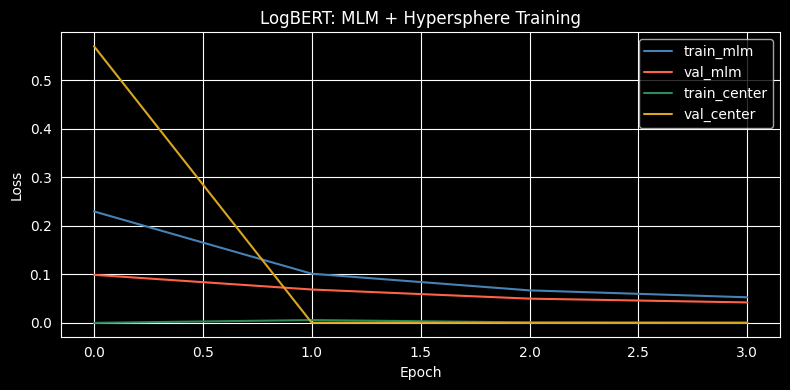

In [14]:
optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_dl) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)


@torch.no_grad()
def compute_center(data_loader):
    model.eval()
    embeds = []
    for batch in data_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            output_hidden_states=True,
            return_dict=True,
        )
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        embeds.append(dist_emb)
    center = torch.cat(embeds, dim=0).mean(dim=0)
    return F.normalize(center, dim=0)


@torch.no_grad()
def compute_center_loss(data_loader, center):
    model.eval()
    losses = []
    for batch in data_loader:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            output_hidden_states=True,
            return_dict=True,
        )
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        losses.append(((dist_emb - center) ** 2).sum(dim=1).mean().item())
    return float(np.mean(losses)) if losses else 0.0


train_losses, val_losses = [], []
train_mlm_losses, val_mlm_losses = [], []
train_center_losses, val_center_losses = [], []
best_val_loss, patience_cnt = float("inf"), 0
center = None

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_total, ep_mlm, ep_center = 0.0, 0.0, 0.0

    for batch in train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        out = model(**batch, output_hidden_states=True, return_dict=True)
        mlm_loss = out.loss
        center_loss = torch.tensor(0.0, device=DEVICE)

        if center is not None and epoch >= CENTER_WARMUP_EPOCH:
            dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
            center_loss = ((dist_emb - center) ** 2).sum(dim=1).mean()

        loss = mlm_loss + CENTER_LOSS_WEIGHT * center_loss

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        ep_total += loss.item()
        ep_mlm += mlm_loss.item()
        ep_center += center_loss.item()

    center = compute_center(train_embed_dl)
    train_losses.append(ep_total / len(train_dl))
    train_mlm_losses.append(ep_mlm / len(train_dl))
    train_center_losses.append(ep_center / len(train_dl))

    model.eval()
    vl_total, vl_mlm = 0.0, 0.0
    with torch.no_grad():
        for batch in val_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch, output_hidden_states=True, return_dict=True)
            vl_mlm += out.loss.item()
            vl_total += out.loss.item()

    val_center = compute_center_loss(val_embed_dl, center)
    val_mlm = vl_mlm / len(val_dl)
    val_total = (vl_total / len(val_dl)) + CENTER_LOSS_WEIGHT * val_center

    val_losses.append(val_total)
    val_mlm_losses.append(val_mlm)
    val_center_losses.append(val_center)

    print(
            f"Epoch {epoch:>3}/{EPOCHS}  "
            f"train_total={train_losses[-1]:.4f}  "
            f"train_mlm={train_mlm_losses[-1]:.4f}  "
            f"train_center={train_center_losses[-1]:.4f}  "
            f"val_total={val_losses[-1]:.4f}"
    )

    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "center": center.detach().cpu(),
            },
            OUTPUT_DIR / "logbert_best.pt",
        )
        patience_cnt = 0
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}")
            break

checkpoint = torch.load(OUTPUT_DIR / "logbert_best.pt", map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
center = checkpoint["center"].to(DEVICE)
print(f"\nBest val loss: {best_val_loss:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_mlm_losses, label="train_mlm", color="steelblue")
ax.plot(val_mlm_losses, label="val_mlm", color="tomato")
ax.plot(train_center_losses, label="train_center", color="seagreen")
ax.plot(val_center_losses, label="val_center", color="goldenrod")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("LogBERT: MLM + Hypersphere Training")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "logbert_training_loss.png", dpi=150)
plt.show()


## 3. Метрики качества

Сначала validation-набор используется для калибровки шкалы и выбора порога. Затем тестовый набор оценивается в той же шкале, а итоговые метрики и артефакты сохраняются на диск.


Scoring validation set…


MLM inference rounds:   0%|          | 0/3 [00:00<?, ?it/s]

Anomaly threshold (95th pct of val normals): 0.0003
Scoring test set…


MLM inference rounds:   0%|          | 0/3 [00:00<?, ?it/s]


Metric          Value
----------------------
Precision      0.8170
Recall         0.7342
F1             0.7734
ROC-AUC        0.9152
PR-AUC         0.8593


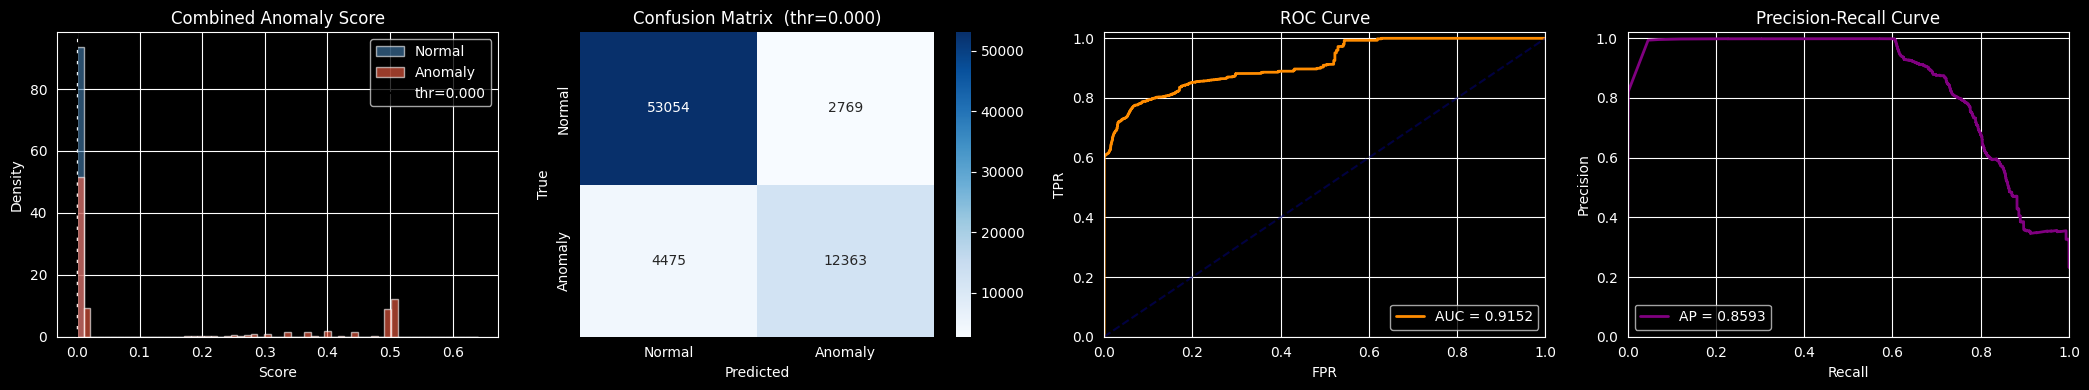


Artifacts saved to: /content/logbert


,dataset_root,output_dir,threshold,precision,recall,f1,roc_auc,pr_auc,mlm_score_weight,center_score_weight,center_loss_weight,sequence_token,position_embedding,mlm_scaling_bounds,center_scaling_bounds,train_normal,val_normal,test_normal,test_anomaly,test_total
0,/content/hdfs_download,/content/logbert,0.000266,0.817,0.7342,0.7734,0.9152,0.8593,0.5,0.5,0.1,[DIST],sinusoidal_frozen,"[0.0, 0.125]","[2e-06, 0.223232]",446578,55822,55823,16838,72661


In [15]:
@torch.no_grad()
def compute_mlm_anomaly_scores(sequences, n_rounds=INFER_ROUNDS,
                               top_g=TOP_G, batch_size=INFER_BATCH):
    model.eval()
    max_content = WINDOW_SIZE - 2

    sess_wins = []
    for seq in sequences:
        enc = encode_seq(seq)
        sess_wins.append(split_windows(enc, max_content))

    wrong = np.zeros(len(sequences), np.int64)
    masked = np.zeros(len(sequences), np.int64)

    for _ in tqdm(range(n_rounds), desc="MLM inference rounds"):
        b_inp, b_attn, b_lbls, b_sidx = [], [], [], []

        for sidx, wins in enumerate(sess_wins):
            for win in wins:
                ids = [DIST_ID] + win + [SEP_ID]
                pad = WINDOW_SIZE - len(ids)
                attn = [1] * len(ids) + [0] * pad
                ids = ids + [PAD_ID] * pad
                inp = ids[:]
                lbls = {}

                for i in range(1, len(win) + 1):
                    if random.random() < MASK_PROB:
                        lbls[i] = inp[i]
                        inp[i] = MASK_ID

                if not lbls and len(win) > 0:
                    forced_pos = random.randint(1, len(win))
                    lbls[forced_pos] = inp[forced_pos]
                    inp[forced_pos] = MASK_ID

                if not lbls:
                    continue

                b_inp.append(inp)
                b_attn.append(attn)
                b_lbls.append(lbls)
                b_sidx.append(sidx)

        for start in range(0, len(b_inp), batch_size):
            end = start + batch_size
            inp_t = torch.tensor(b_inp[start:end], dtype=torch.long, device=DEVICE)
            att_t = torch.tensor(b_attn[start:end], dtype=torch.long, device=DEVICE)
            logits = model(input_ids=inp_t, attention_mask=att_t, return_dict=True).logits

            for j, (lbls, sidx) in enumerate(zip(b_lbls[start:end], b_sidx[start:end])):
                for pos, true_id in lbls.items():
                    top_preds = logits[j, pos].topk(top_g).indices.tolist()
                    masked[sidx] += 1
                    if true_id not in top_preds:
                        wrong[sidx] += 1

    scores = np.zeros(len(sequences), dtype=np.float64)
    valid = masked > 0
    scores[valid] = wrong[valid] / masked[valid]
    return scores


@torch.no_grad()
def compute_center_distances(sequences, center, batch_size=INFER_BATCH):
    model.eval()
    max_content = WINDOW_SIZE - 2

    all_inputs, all_attn, all_sidx = [], [], []
    for sidx, seq in enumerate(sequences):
        enc = encode_seq(seq)
        for win in split_windows(enc, max_content):
            ids = [DIST_ID] + win + [SEP_ID]
            pad = WINDOW_SIZE - len(ids)
            attn = [1] * len(ids) + [0] * pad
            ids = ids + [PAD_ID] * pad
            all_inputs.append(ids)
            all_attn.append(attn)
            all_sidx.append(sidx)

    dist_sum = np.zeros(len(sequences), dtype=np.float64)
    dist_cnt = np.zeros(len(sequences), dtype=np.int64)

    for start in range(0, len(all_inputs), batch_size):
        end = start + batch_size
        inp_t = torch.tensor(all_inputs[start:end], dtype=torch.long, device=DEVICE)
        att_t = torch.tensor(all_attn[start:end], dtype=torch.long, device=DEVICE)
        out = model(input_ids=inp_t, attention_mask=att_t, output_hidden_states=True, return_dict=True)
        dist_emb = F.normalize(out.hidden_states[-1][:, 0, :], dim=1)
        dists = ((dist_emb - center) ** 2).sum(dim=1).detach().cpu().numpy()

        for dist, sidx in zip(dists, all_sidx[start:end]):
            dist_sum[sidx] += dist
            dist_cnt[sidx] += 1

    scores = np.zeros(len(sequences), dtype=np.float64)
    valid = dist_cnt > 0
    scores[valid] = dist_sum[valid] / dist_cnt[valid]
    return scores


def fit_minmax(scores):
    scores = np.asarray(scores, dtype=np.float64)
    return float(scores.min()), float(scores.max())


def apply_minmax(scores, bounds):
    scores = np.asarray(scores, dtype=np.float64)
    lo, hi = bounds
    if hi - lo < 1e-12:
        return np.zeros_like(scores)
    return np.clip((scores - lo) / (hi - lo), 0.0, 1.0)


def combine_scores(mlm_scores, center_scores, mlm_bounds, center_bounds):
    mlm_scaled = apply_minmax(mlm_scores, mlm_bounds)
    center_scaled = apply_minmax(center_scores, center_bounds)
    combined = MLM_SCORE_WEIGHT * mlm_scaled + CENTER_SCORE_WEIGHT * center_scaled
    return combined, mlm_scaled, center_scaled


print("Scoring validation set…")
val_mlm_scores = compute_mlm_anomaly_scores(val_seqs)
val_center_scores = compute_center_distances(val_seqs, center)
mlm_bounds = fit_minmax(val_mlm_scores)
center_bounds = fit_minmax(val_center_scores)
val_scores, val_mlm_scaled, val_center_scaled = combine_scores(
    val_mlm_scores, val_center_scores, mlm_bounds, center_bounds
)

THRESHOLD = float(np.percentile(val_scores, 95))
print(f"Anomaly threshold (95th pct of val normals): {THRESHOLD:.4f}")

print("Scoring test set…")
test_mlm_scores = compute_mlm_anomaly_scores(test_seqs)
test_center_scores = compute_center_distances(test_seqs, center)
test_scores, test_mlm_scaled, test_center_scaled = combine_scores(
    test_mlm_scores, test_center_scores, mlm_bounds, center_bounds
)
test_lbls_arr = np.array(test_lbls, dtype=int)
test_preds = (test_scores >= THRESHOLD).astype(int)

prec = precision_score(test_lbls_arr, test_preds, zero_division=0)
rec = recall_score(test_lbls_arr, test_preds)
f1 = f1_score(test_lbls_arr, test_preds)
auc = roc_auc_score(test_lbls_arr, test_scores)
pr_auc = average_precision_score(test_lbls_arr, test_scores)

print(f"\n{'Metric':<12} {'Value':>8}")
print("-" * 22)
for name, val in [("Precision", prec), ("Recall", rec), ("F1", f1), ("ROC-AUC", auc), ("PR-AUC", pr_auc)]:
    print(f"{name:<12} {val:>8.4f}")

fig, axes = plt.subplots(1, 4, figsize=(21, 4))

normal_sc = test_scores[test_lbls_arr == 0]
anomaly_sc = test_scores[test_lbls_arr == 1]
axes[0].hist(normal_sc, bins=60, alpha=0.6, label="Normal", color="steelblue", density=True)
axes[0].hist(anomaly_sc, bins=60, alpha=0.6, label="Anomaly", color="tomato", density=True)
axes[0].axvline(THRESHOLD, color="black", ls="--", label=f"thr={THRESHOLD:.3f}")
axes[0].set_title("Combined Anomaly Score")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Density")
axes[0].legend()

cm = confusion_matrix(test_lbls_arr, test_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=["Normal", "Anomaly"],
            yticklabels=["Normal", "Anomaly"])
axes[1].set_title(f"Confusion Matrix  (thr={THRESHOLD:.3f})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

fpr_arr, tpr_arr, _ = roc_curve(test_lbls_arr, test_scores)
axes[2].plot(fpr_arr, tpr_arr, color="darkorange", lw=2, label=f"AUC = {auc:.4f}")
axes[2].plot([0, 1], [0, 1], color="navy", ls="--", alpha=0.5)
axes[2].set_xlim([0, 1])
axes[2].set_ylim([0, 1.02])
axes[2].set_xlabel("FPR")
axes[2].set_ylabel("TPR")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")

pr_prec_arr, pr_rec_arr, _ = precision_recall_curve(test_lbls_arr, test_scores)
axes[3].plot(pr_rec_arr, pr_prec_arr, color="purple", lw=2, label=f"AP = {pr_auc:.4f}")
axes[3].set_xlim([0, 1])
axes[3].set_ylim([0, 1.02])
axes[3].set_xlabel("Recall")
axes[3].set_ylabel("Precision")
axes[3].set_title("Precision-Recall Curve")
axes[3].legend(loc="lower left")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "logbert_evaluation.png", dpi=150)
plt.show()

split_summary = {
    "train_normal": len(tr_seqs),
    "val_normal": len(val_seqs),
    "test_normal": int((test_lbls_arr == 0).sum()),
    "test_anomaly": int((test_lbls_arr == 1).sum()),
    "test_total": len(test_seqs),
}

results = {
    "dataset_root": str(dataset_root),
    "output_dir": str(OUTPUT_DIR),
    "threshold": THRESHOLD,
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1": round(f1, 4),
    "roc_auc": round(auc, 4),
    "pr_auc": round(pr_auc, 4),
    "mlm_score_weight": MLM_SCORE_WEIGHT,
    "center_score_weight": CENTER_SCORE_WEIGHT,
    "center_loss_weight": CENTER_LOSS_WEIGHT,
    "sequence_token": DIST_TOKEN,
    "position_embedding": "sinusoidal_frozen",
    "mlm_scaling_bounds": [round(mlm_bounds[0], 6), round(mlm_bounds[1], 6)],
    "center_scaling_bounds": [round(center_bounds[0], 6), round(center_bounds[1], 6)],
    **split_summary,
}

results_df = pd.DataFrame([results])
results_json_output = OUTPUT_DIR / "logbert_results.json"
results_csv_output = OUTPUT_DIR / "logbert_results.csv"
config_output = OUTPUT_DIR / "logbert_config.json"

np.save(OUTPUT_DIR / "logbert_test_scores.npy", test_scores)
np.save(OUTPUT_DIR / "logbert_test_labels.npy", test_lbls_arr)
np.save(OUTPUT_DIR / "logbert_test_mlm_scores.npy", test_mlm_scores)
np.save(OUTPUT_DIR / "logbert_test_center_scores.npy", test_center_scores)
torch.save(center.detach().cpu(), OUTPUT_DIR / "logbert_center.pt")
results_json_output.write_text(json.dumps(results, indent=2), encoding="utf-8")
results_df.to_csv(results_csv_output, index=False)
config_output.write_text(json.dumps(CONFIG, indent=2), encoding="utf-8")

print(f"\nArtifacts saved to: {OUTPUT_DIR}")
results_df
